In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# 1. 导入数据集
print("=== 1. 导入数据集 ===")
df = pd.read_csv('house_price_final_train_dataset2.csv')
print(f"数据集形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")

=== 1. 导入数据集 ===
数据集形状: (103871, 65)
列名: ['Price', 'lnPrice', 'decoration_精装', 'decoration_简装', 'decoration_毛坯', 'decoration_其他', 'high_dummy', 'middle_dummy', 'low_dummy', 'basement_dummy', 'top_dummy', 'bottom_dummy', 'total_floor', 'area', 'room_count', 'hall_count', 'south_dummy', 'north_south_dummy', 'trans_2024', 'trans_2025', '梯数', '户数', 'elevator_yes', 'transaction_commercial', 'transaction_non_commercial', 'usage_commercial_office', 'usage_commercial_residential', 'usage_high_end_residential', 'usage_ordinary_residential', 'usage_other_special', 'house_age_over_2_years', 'house_age_over_5_years', 'house_age_under_2_years', 'subway', 'building_age', 'household_total', 'building_total', 'greening_rate', 'plot_ratio', 'structure_material_brick_concrete', 'structure_material_brick_wood', 'structure_material_frame', 'structure_material_mixed', 'structure_material_steel', 'structure_material_steel_concrete', 'structure_material_unknown', 'property_fee_avg', 'water_civil', 'water_com

In [3]:
# 3. 添加特征
print("\n=== 3. 添加特征 ===")

# 3.1 添加area^2变量
if 'area' in df.columns:
    # 删除可能已存在的area^2
    if 'area^2' in df.columns:
        df.drop('area^2', axis=1, inplace=True)
        print("已删除已存在的area^2")
    
    # 添加area^2
    df['area^2'] = df['area'] ** 2
    print("已添加area^2变量")
else:
    print("数据集中没有area变量")

# 3.2 添加城市哑变量
print("\n=== 3.2 添加城市哑变量 ===")

if '城市' in df.columns:
    # 删除可能已存在的城市哑变量
    city_dummy_cols = [col for col in df.columns if col.startswith('city_')]
    if city_dummy_cols:
        df.drop(city_dummy_cols, axis=1, inplace=True)
        print(f"已删除已存在的城市哑变量: {city_dummy_cols}")
    
    # 获取城市唯一值并排序
    unique_cities = sorted(df['城市'].unique())
    print(f"城市唯一值: {unique_cities}")
    
    # 创建城市哑变量
    for city_num in unique_cities:
        col_name = f'city_{city_num}'
        df[col_name] = (df['城市'] == city_num).astype(int)
    
    # 验证创建结果
    created_city_cols = [col for col in df.columns if col.startswith('city_')]
    print(f"已创建 {len(created_city_cols)} 个城市哑变量: {created_city_cols}")
    
    # 显示每个城市哑变量的样本数量
    for col in created_city_cols:
        count = df[col].sum()
        print(f"{col}: {count} 个样本")
else:
    print("数据集中没有'city'列，无法创建城市哑变量")

# 3.3 添加城市与距离的交互项
print("\n=== 3.3 添加城市与距离的交互项 ===")

if '城市' in df.columns and '距市中心距离_km' in df.columns:
    # 删除可能已存在的交互项
    interaction_cols = [col for col in df.columns if col.startswith('city_dist_')]
    if interaction_cols:
        df.drop(interaction_cols, axis=1, inplace=True)
        print(f"已删除已存在的交互项: {interaction_cols}")
    
    # 为每个城市创建与距离的交互项
    for city_num in unique_cities:
        col_name = f'city_dist_{city_num}'
        df[col_name] = df[f'city_{city_num}'] * df['距市中心距离_km']
    
    # 验证创建结果
    created_interaction_cols = [col for col in df.columns if col.startswith('city_dist_')]
    print(f"已创建 {len(created_interaction_cols)} 个城市-距离交互项: {created_interaction_cols}")
    
    # 显示交互项的基本统计信息
    for col in created_interaction_cols:
        non_zero_count = (df[col] != 0).sum()
        print(f"{col}: {non_zero_count} 个非零值, 均值={df[col].mean():.2f}")
else:
    print("缺少'city'或'距市中心距离_km'列，无法创建交互项")


=== 3. 添加特征 ===
已添加area^2变量

=== 3.2 添加城市哑变量 ===
城市唯一值: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
已创建 12 个城市哑变量: ['city_0', 'city_1', 'city_2', 'city_3', 'city_4', 'city_5', 'city_6', 'city_7', 'city_8', 'city_9', 'city_10', 'city_11']
city_0: 16491 个样本
city_1: 6437 个样本
city_2: 24996 个样本
city_3: 21472 个样本
city_4: 4363 个样本
city_5: 3582 个样本
city_6: 2281 个样本
city_7: 1184 个样本
city_8: 5931 个样本
city_9: 1323 个样本
city_10: 15057 个样本
city_11: 754 个样本

=== 3.3 添加城市与距离的交互项 ===
已创建 12 个城市-距离交互项: ['city_dist_0', 'city_dist_1', 'city_dist_2', 'city_dist_3', 'city_dist_4', 'city_dist_5', 'city_dist_6', 'city_dist_7', 'city_dist_8', 'city_dist_9', 'city_dist_10', 'city_dist_11']
city_dist_0: 16491 个非零值, 均值=23.59
city_dist_1: 6437 个非零值, 均值=9.53
city_dist_2: 24996 个非零值, 均值=43.90
city_dist_3: 21472 个非零值, 均值=4.54
city_dist_4: 4363 个非零值, 均值=6.17
city_dist_5: 3582 个非零值, 均值=4.90
city_dist_6: 2

In [4]:
# 4. 使用IQR方法剔除离群点
print("\n=== 4. 使用IQR方法剔除离群点 ===")

# 识别连续型自变量（排除因变量和哑变量）
continuous_vars = []
exclude_vars = ['Price', 'lnPrice', 'price'] + [col for col in df.columns if col.startswith('city_')]
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].nunique() > 10 and col not in exclude_vars:
        continuous_vars.append(col)

print(f"连续型自变量数量: {len(continuous_vars)}")
print(f"连续型自变量: {continuous_vars}")

# 使用IQR方法识别离群点
def detect_outliers_iqr(df, columns, multiplier=3):
    outlier_indices = set()
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        # 找出离群点的索引
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers)
        
        print(f"{col}: 离群点数量 = {len(outliers)} (边界: [{lower_bound:.2f}, {upper_bound:.2f}])")
    
    return list(outlier_indices)

# 使用系数3检测离群点，但只对自变量
outlier_indices = detect_outliers_iqr(df, continuous_vars, multiplier=3)
print(f"\n总共检测到 {len(outlier_indices)} 个离群点")

# 计算每个样本的离群点数量，只剔除有多个离群点的样本
from collections import Counter
outlier_counts = Counter(outlier_indices)

# 设置阈值：如果一个样本在多个变量上都是离群点，则剔除
threshold = 2
extreme_outliers = [idx for idx, count in outlier_counts.items() if count >= threshold]

print(f"有 {len(extreme_outliers)} 个样本在 {threshold} 个或以上变量上是离群点")

# 剔除极端离群点
original_shape = df.shape
df_clean = df.drop(extreme_outliers)
print(f"剔除离群点后数据集形状: {original_shape} -> {df_clean.shape}")
print(f"剔除了 {len(extreme_outliers)} 行数据，占总数据的 {len(extreme_outliers)/original_shape[0]*100:.2f}%")


=== 4. 使用IQR方法剔除离群点 ===
连续型自变量数量: 19
连续型自变量: ['total_floor', 'area', 'room_count', '梯数', '户数', 'building_age', 'household_total', 'building_total', 'greening_rate', 'plot_ratio', 'property_fee_avg', 'gas_fee_avg', 'heating_fee_avg', 'parking_spots', '城市', '区县', '板块', '距市中心距离_km', 'area^2']
total_floor: 离群点数量 = 0 (边界: [-56.00, 91.00])
area: 离群点数量 = 1468 (边界: [-72.36, 262.10])
room_count: 离群点数量 = 194 (边界: [-1.00, 6.00])
梯数: 离群点数量 = 1633 (边界: [-2.00, 5.00])
户数: 离群点数量 = 4127 (边界: [-13.00, 22.00])
building_age: 离群点数量 = 448 (边界: [-12.00, 37.00])
household_total: 离群点数量 = 2951 (边界: [-4200.00, 7322.00])
building_total: 离群点数量 = 5429 (边界: [-53.00, 87.00])
greening_rate: 离群点数量 = 2357 (边界: [0.00, 0.01])
plot_ratio: 离群点数量 = 1972 (边界: [-3.00, 7.50])
property_fee_avg: 离群点数量 = 2320 (边界: [-4.30, 7.60])
gas_fee_avg: 离群点数量 = 0 (边界: [-0.40, 5.55])
heating_fee_avg: 离群点数量 = 0 (边界: [-82.16, 114.12])
parking_spots: 离群点数量 = 3911 (边界: [-2000.00, 3600.00])
城市: 离群点数量 = 0 (边界: [-10.00, 18.00])
区县: 离群点数量 = 0 (边界: [


=== 5. 探究自变量与lnPrice的关系 ===

所有变量与lnPrice的相关系数（绝对值）:
Price: 0.820
area: 0.475
city_0: 0.448
city_dist_0: 0.447
area^2: 0.407
city_2: 0.333
city_dist_2: 0.332
room_count: 0.326
heating_fee_avg: 0.306
building_age: 0.288
property_phone_yes: 0.247
户数: 0.247
gas_fee_avg: 0.234
city_6: 0.223
subway: 0.223
city_dist_6: 0.222
city_4: 0.202
city_dist_4: 0.201
usage_commercial_residential: 0.201
heating_central: 0.187
house_age_over_5_years: 0.186
usage_other_special: 0.179
bottom_dummy: 0.167
city_1: 0.163
north_south_dummy: 0.158
heating_self: 0.158
city_dist_1: 0.154
梯数: 0.141
usage_high_end_residential: 0.140
usage_ordinary_residential: 0.135
top_dummy: 0.133
basement_dummy: 0.133
hall_count: 0.130
decoration_精装: 0.129
decoration_其他: 0.126
距市中心距离_km: 0.126
structure_material_unknown: 0.121
城市: 0.118
city_dist_8: 0.114
city_8: 0.113
structure_material_mixed: 0.110
city_9: 0.103
transaction_commercial: 0.096
transaction_non_commercial: 0.096
trans_2024: 0.095
city_7: 0.084
property_fee_avg: 

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8004\1683535105.py:40: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8004\1683535105.py:40: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8004\1683535105.py:40: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8004\1683535105.py:40: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lenovo\AppData\Local\Progra

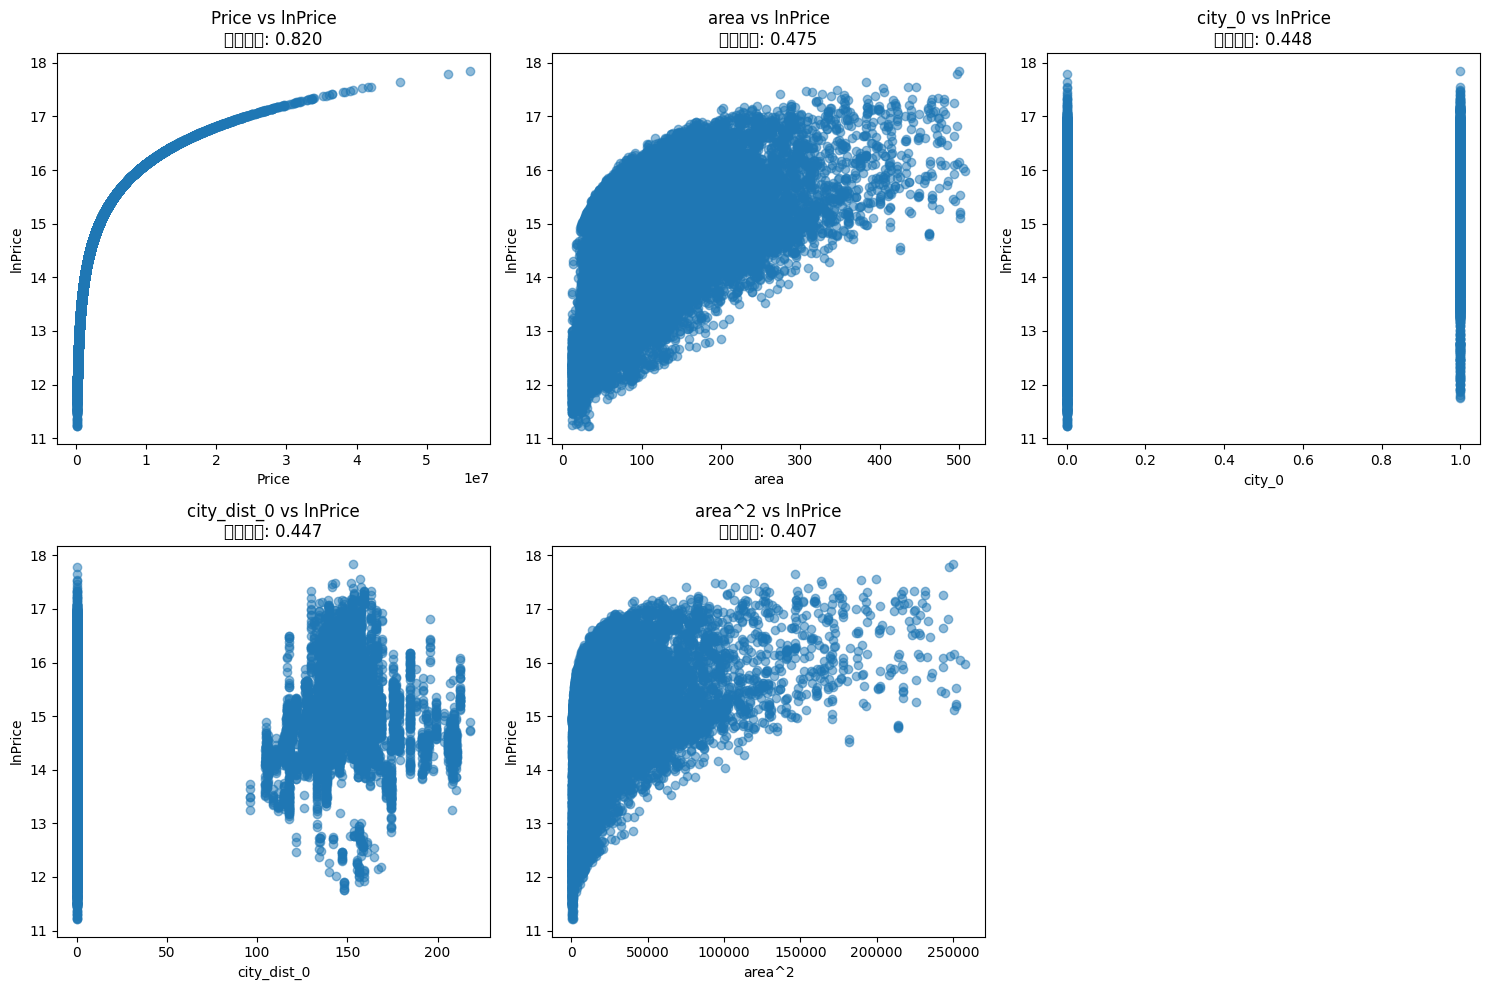

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8004\1683535105.py:57: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8004\1683535105.py:57: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8004\1683535105.py:57: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8004\1683535105.py:57: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


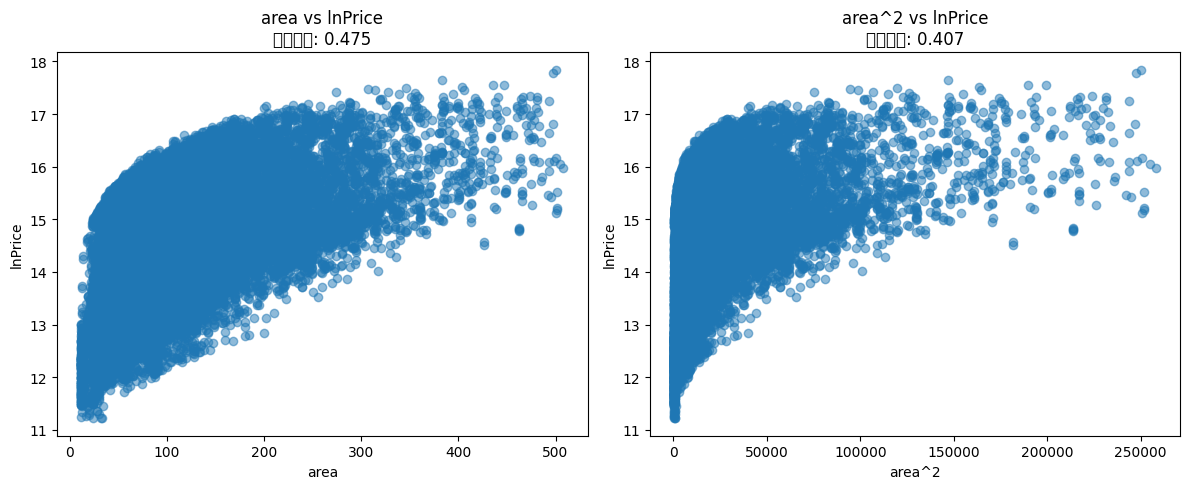

In [5]:
# 5. 探究自变量与因变量lnPrice的关系
print("\n=== 5. 探究自变量与lnPrice的关系 ===")

# 检查是否有lnPrice列，如果没有则创建
if 'lnPrice' not in df_clean.columns and 'Price' in df_clean.columns:
    df_clean['lnPrice'] = np.log(df_clean['Price'])
    print("已创建lnPrice变量")

if 'lnPrice' in df_clean.columns:
    # 计算所有数值变量与lnPrice的相关系数
    numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    correlations = df_clean[numeric_cols_clean].corr()['lnPrice'].abs().sort_values(ascending=False)
    
    print("\n所有变量与lnPrice的相关系数（绝对值）:")
    for var, corr in correlations.items():
        if var != 'lnPrice':
            print(f"{var}: {corr:.3f}")
    
    # 选择与lnPrice相关性最高的几个变量绘制散点图
    top_vars = correlations[1:6].index.tolist()
    
    print(f"\n绘制与lnPrice相关性最高的 {len(top_vars)} 个变量的散点图:")
    print(top_vars)
    
    # 绘制散点图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i, var in enumerate(top_vars):
        if i < len(axes):
            axes[i].scatter(df_clean[var], df_clean['lnPrice'], alpha=0.5)
            axes[i].set_xlabel(var)
            axes[i].set_ylabel('lnPrice')
            axes[i].set_title(f'{var} vs lnPrice\n相关系数: {correlations[var]:.3f}')
    
    # 隐藏多余的子图
    for i in range(len(top_vars), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 绘制area和area^2与lnPrice的关系
    if 'area' in df_clean.columns and 'area^2' in df_clean.columns:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        ax1.scatter(df_clean['area'], df_clean['lnPrice'], alpha=0.5)
        ax1.set_xlabel('area')
        ax1.set_ylabel('lnPrice')
        ax1.set_title(f'area vs lnPrice\n相关系数: {correlations["area"]:.3f}')
        
        ax2.scatter(df_clean['area^2'], df_clean['lnPrice'], alpha=0.5)
        ax2.set_xlabel('area^2')
        ax2.set_ylabel('lnPrice')
        ax2.set_title(f'area^2 vs lnPrice\n相关系数: {correlations["area^2"]:.3f}')
        
        plt.tight_layout()
        plt.show()
else:
    print("数据集中没有lnPrice或Price变量，无法进行相关性分析")

In [6]:
# 7. 保存最终数据集
print("\n=== 7. 保存最终数据集 ===")
df_clean.to_csv("house_price_final_train_dataset3.csv", index=False)
print("数据集已保存为 house_price_final_train_dataset3.csv")
print(f"最终数据集形状: {df_clean.shape}")

print("\n数据集简要统计信息:")
print(df_clean.describe())

print("\n=== 处理完成 ===")


=== 7. 保存最终数据集 ===
数据集已保存为 house_price_final_train_dataset3.csv
最终数据集形状: (103871, 90)

数据集简要统计信息:
              Price        lnPrice  decoration_精装  decoration_简装  \
count  1.038710e+05  103871.000000  103871.000000  103871.000000   
mean   2.262366e+06      14.262815       0.452022       0.197572   
std    2.532925e+06       0.830043       0.497695       0.398169   
min    7.455330e+04      11.219270       0.000000       0.000000   
25%    8.910913e+05      13.700202       0.000000       0.000000   
50%    1.479407e+06      14.207152       0.000000       0.000000   
75%    2.680757e+06      14.801610       1.000000       0.000000   
max    5.622643e+07      17.844898       1.000000       1.000000   

       decoration_毛坯  decoration_其他     high_dummy   middle_dummy  \
count  103871.000000  103871.000000  103871.000000  103871.000000   
mean        0.119032       0.229352       0.309345       0.349000   
std         0.323828       0.420418       0.462226       0.476656   
min         